## Applying the function I tested to the full dataset

Importing necessary packages

In [83]:
from shapely import wkt, box, Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, shortest_line
import geopandas as gpd

Reading in housing data

In [85]:
full_map_old = gpd.read_file('data/chi_bldg_footprints.geojson')
full_map = full_map_old.to_crs(epsg=26971)

<hr>

## Dropping NAs

In [86]:
full_map.shape

(820606, 47)

In [87]:
## there are 6 NA values that I will filter out 
full_map[full_map['geometry'].isna()].shape

(6, 47)

In [88]:
full_map = full_map.dropna(subset=['geometry'])

<hr>

## Making sure all `stories` values are actually strings

In [95]:
full_map['stories'] = full_map['stories'].astype('int32')

In [97]:
full_map[full_map['stories'].isna()].shape

(0, 47)

<hr>

Reading in updated CTA data

In [92]:
cta_lines_old = gpd.read_file('data/cta_lines_updated.geojson')
cta_lines_projected = cta_lines_old.to_crs(epsg=26971)
cta_line = cta_lines_projected['geometry'].union_all()

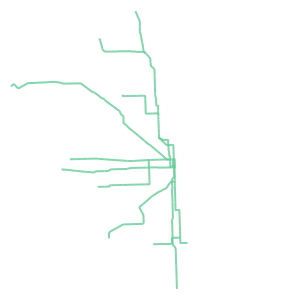

In [98]:
cta_line

Defining my function

In [99]:
def train_noise(row):
    geom = row['geometry']
    id = row[':id']
    ## 1. find the centroid of the building footprint
    centroid = geom.centroid

    ##### go through each train line geom
    ##### find the distances to each one
    ##### find the shortest distance to a train line
    ##### do all my calculations around that one
    ##### find the next closest line
    ##### do all my calculations around that one
    
    ## 2. find the nearest point btwn CTA lines and centroid
    line = shortest_line(centroid, cta_line)
    ## 4. Measure the distance of that line and store it as a datapoint
    ## I believe EPSG 26971 has a base unit of 1 meter, so this length should already be in meters
    line_len = line.length
    ## 5. Identify all building footprints the line intersects
    intersected_buildings = full_map[full_map['geometry'].intersects(line)]

    ## had to add an if/else statement so my logic didn't break if there were no buildings intersected
    if len(intersected_buildings) > 0:
    ## 6. Record the total # of buildings intersected
    ## I do -1 at the end here because I think the .intersects() argument would count the building the line is connecting as a polygon it intersects with
        num_int_bldgs = len(intersected_buildings)-1
    
    ## 7. Record the total height of buildings intersected (# of stories)
        tot_height = sum(intersected_buildings['stories'])

    ## 8.1 Record the max height of buildings intersected
        max_height = max(intersected_buildings['stories'])
    else:
        num_int_bldgs = 0
        tot_height = 0
        max_height = 0

    return {'geom': geom, 'centroid': centroid, 'dist_train': line_len, 'shortest_line_1': line,
            'num_intersections': num_int_bldgs, 'tot_stories': tot_height, 'max_height': max_height}

In [ ]:
from tqdm import tqdm
tqdm.pandas(desc="Train noise")

ndf = full_map.progress_apply(train_noise, axis=1, result_type='expand')

Train noise:  17%|█▋        | 139645/820600 [1:43:49<8:06:09, 23.34it/s] 

In [55]:
map = tops.explore()
map.show_in_browser()

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


In [43]:
full_map[full_map[':id']=="row-deiv~cv2p.hsft"]

,:id,:version,:created_at,:updated_at,bldg_id,cdb_city_i,bldg_statu,f_add1,t_add1,pre_dir1,...,year_built,bldg_sq_fo,bldg_condi,condition_,vacancy_st,label_hous,suf_dir1,shape_area,shape_len,geometry
362,row-deiv~cv2p.hsft,rv-4bh6~zwvp.h76w,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,814782,,ACTIVE,600,600,W,...,1912,0.0,,NaT,,600,,14300.5,673.776495132,"MULTIPOLYGON (((357299.663 578838.01, 357326.6..."
